# What Actually Makes a Premier League Player Worth More?

A plain-English tour through everything we found digging into Premier League transfer values: what really moves the price tag, which players might be worth a lot more a year from now, and whether playing for a "big club" inflates your value beyond what you've actually done on the pitch.

No stats jargon here — just the findings. (If you want the full technical breakdown, it's in the other three notebooks in this project.)

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

from src.panel import build_snapshot_panel
from src.modeling import latest_snapshot_per_player, predict_value_growth, train_horizon_models

sns.set_theme(style="whitegrid", context="talk")
USD_PER_EUR = 1.08

panel = build_snapshot_panel()
panel["current_value_usd_m"] = panel["current_value_eur"] * USD_PER_EUR / 1_000_000
print(f"Loaded {panel.shape[0]:,} historical valuations for Premier League players.")

Loaded 33,743 historical valuations for Premier League players.


## 1. How much is a Premier League player actually worth?

Most players are worth far less than the headline transfer fees you hear about. A small number of superstars pull the average way up — most of the squad is nowhere near that.

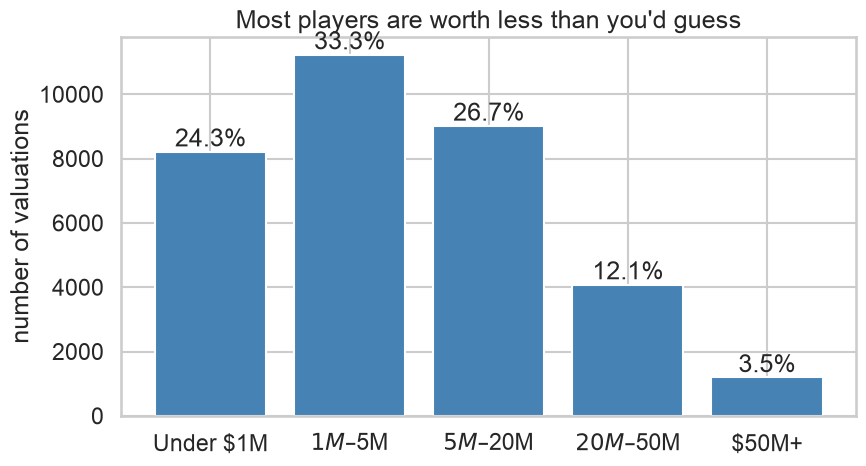

In [2]:
bins = [0, 1, 5, 20, 50, 1000]
labels = ["Under $1M", "$1M\u2013$5M", "$5M\u2013$20M", "$20M\u2013$50M", "$50M+"]
bracket = pd.cut(panel["current_value_usd_m"], bins=bins, labels=labels)
counts = bracket.value_counts().reindex(labels)
pct = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, counts.values, color="steelblue")
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{p}%", ha="center", va="bottom")
ax.set_ylabel("number of valuations")
ax.set_title("Most players are worth less than you'd guess")
plt.tight_layout()
plt.show()

## 2. There's a sweet spot age

Value climbs through a player's early 20s, peaks in the mid-20s, then declines. It's not a straight line — young promise and late-career experience are both worth less than a player in their prime.

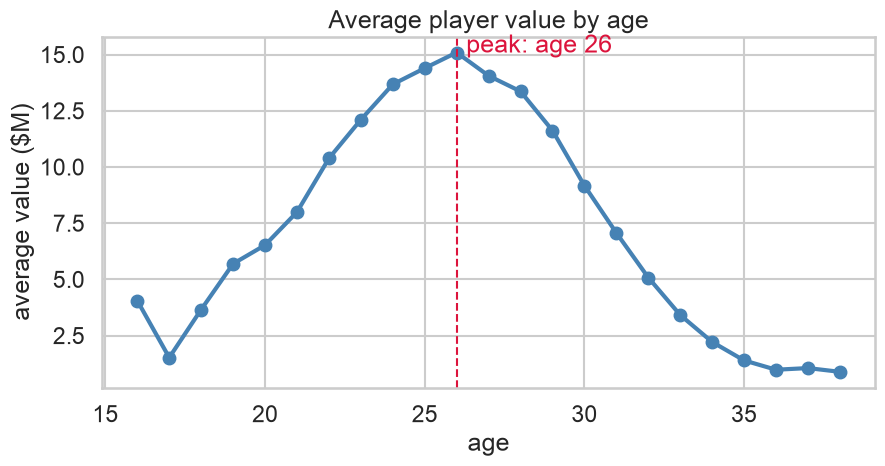

In [3]:
age_curve = panel.dropna(subset=["age"]).groupby(panel["age"].round())["current_value_usd_m"].mean()
age_curve = age_curve[(age_curve.index >= 16) & (age_curve.index <= 38)]
peak_age = int(age_curve.idxmax())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age_curve.index, age_curve.values, color="steelblue", linewidth=3, marker="o")
ax.axvline(peak_age, color="crimson", linestyle="--", linewidth=1.5)
ax.text(peak_age + 0.3, age_curve.max(), f"peak: age {peak_age}", color="crimson")
ax.set_xlabel("age")
ax.set_ylabel("average value ($M)")
ax.set_title("Average player value by age")
plt.tight_layout()
plt.show()

## 3. What actually moves the needle on value?

Scoring goals helps, obviously. But just being trusted with regular game time — playing every week, racking up minutes — matters at least as much as the goals themselves. A super-sub who scores in flashes is worth less than a guaranteed starter, even at similar output.

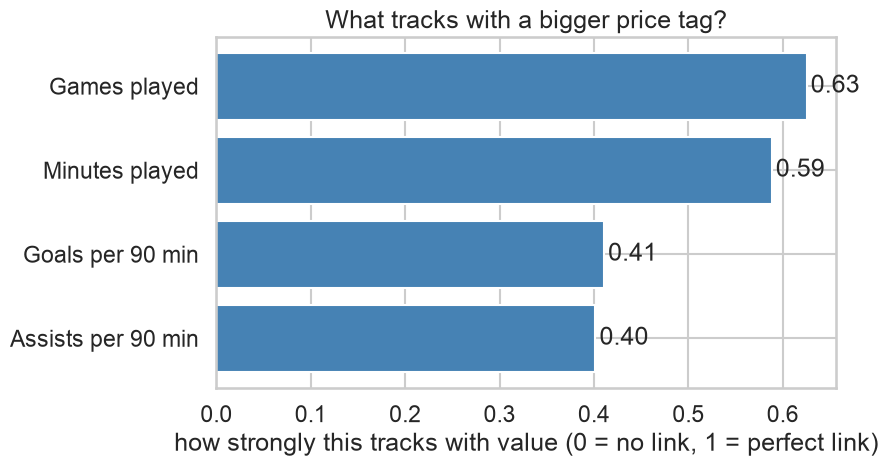

In [4]:
FRIENDLY_LABELS = {
    "trailing_goals_per90": "Goals per 90 min",
    "trailing_assists_per90": "Assists per 90 min",
    "trailing_minutes": "Minutes played",
    "trailing_appearances": "Games played",
}

log_value = np.log10(panel["current_value_eur"])
corr = panel[list(FRIENDLY_LABELS)].corrwith(log_value).rename(FRIENDLY_LABELS).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr.index, corr.values, color="steelblue")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlabel("how strongly this tracks with value (0 = no link, 1 = perfect link)")
ax.set_title("What tracks with a bigger price tag?")
plt.tight_layout()
plt.show()

## 4. Some positions just pay better

Flashy attacking positions carry a real premium — attacking midfielders and wingers are valued well above the league average, position for position, while goalkeepers and defensive-minded midfielders sit well below it.

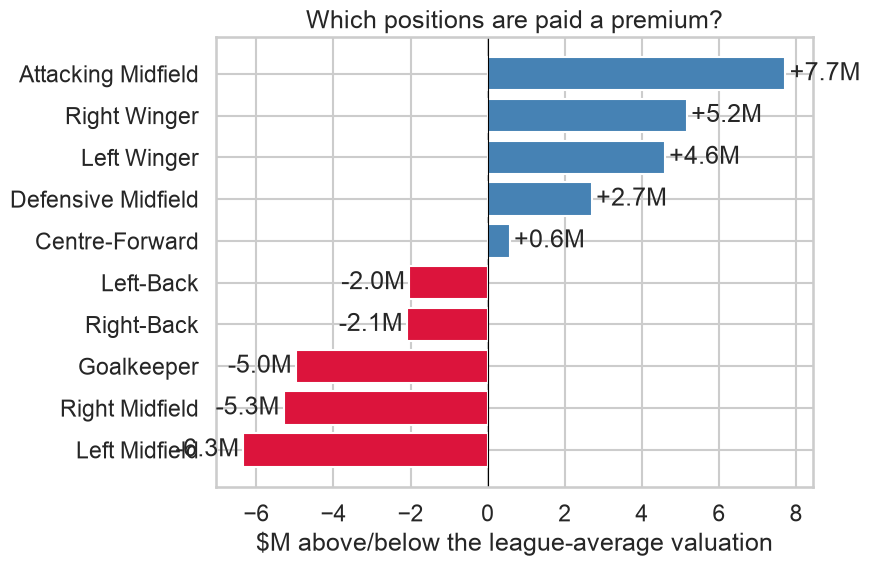

In [5]:
pos_stats = panel.groupby("sub_position")["current_value_usd_m"].agg(["mean", "count"])
pos_stats = pos_stats[pos_stats["count"] >= 15]
pos_stats["deviation"] = pos_stats["mean"] - panel["current_value_usd_m"].mean()
top_bottom = pd.concat([pos_stats.sort_values("deviation").head(5), pos_stats.sort_values("deviation").tail(5)]).sort_values("deviation")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["crimson" if v < 0 else "steelblue" for v in top_bottom["deviation"]]
bars = ax.barh(top_bottom.index, top_bottom["deviation"], color=colors)
ax.bar_label(bars, fmt="%+.1fM", padding=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("$M above/below the league-average valuation")
ax.set_title("Which positions are paid a premium?")
plt.tight_layout()
plt.show()

## 5. Ones to watch: predicted to jump in value

We trained a model on age, recent form, and career history to project how much each player's value might change over the next 12 months, then applied it to every player's latest valuation. Here's who it flags as the biggest projected risers, in dollar terms.

In [6]:
growth_results = train_horizon_models(panel, months=12)
best_model_name = min(growth_results, key=lambda name: growth_results[name]["mae"])
best_pipeline = growth_results[best_model_name]["pipeline"]

latest = latest_snapshot_per_player(panel)
preds = predict_value_growth(best_pipeline, latest)
preds["Current value"] = (preds["current_value_eur"] * USD_PER_EUR / 1_000_000).round(1).map("${}M".format)
preds["Predicted in 12 months"] = (preds["predicted_value_eur"] * USD_PER_EUR / 1_000_000).round(1).map("${}M".format)
preds["Projected change"] = (preds["predicted_pct_change"] * 100).round(0).astype(int).map("+{}%".format)

top10 = preds.sort_values("predicted_eur_change", ascending=False).head(10)
top10 = top10.rename(columns={"name": "Player", "sub_position": "Position"})
top10[["Player", "Position", "Current value", "Predicted in 12 months", "Projected change"]].reset_index(drop=True)

,Player,Position,Current value,Predicted in 12 months,Projected change
0,Max Dowman,Right Winger,$32.4M,$86.3M,+166%
1,Rio Ngumoha,Left Winger,$32.4M,$67.5M,+108%
2,Ethan Nwaneri,Attacking Midfield,$43.2M,$75.7M,+75%
3,Junior Kroupi,Centre-Forward,$75.6M,$105.3M,+39%
4,Rayan,Right Winger,$64.8M,$92.3M,+42%
5,Nico O'Reilly,Left-Back,$75.6M,$97.9M,+30%
6,Mateus Fernandes,Central Midfield,$54.0M,$73.5M,+36%
7,Ayden Heaven,Centre-Back,$32.4M,$51.5M,+59%
8,Harrison Armstrong,Central Midfield,$13.0M,$31.0M,+139%
9,Giovanni Leoni,Centre-Back,$27.0M,$44.7M,+66%


*Take this as a data-driven hunch, not a guarantee — the model only knows age, form, and history. It has no idea about injuries, transfer gossip, or contract standoffs.*

## 6. Does playing for a big club inflate your value?

Short answer: **yes, noticeably**. We built a model that predicts value purely from what a player has actually done on the pitch — age, output, minutes, position — with no knowledge of which club they play for. Comparing real values to that stats-only prediction shows a clear gap for the traditional "big six."

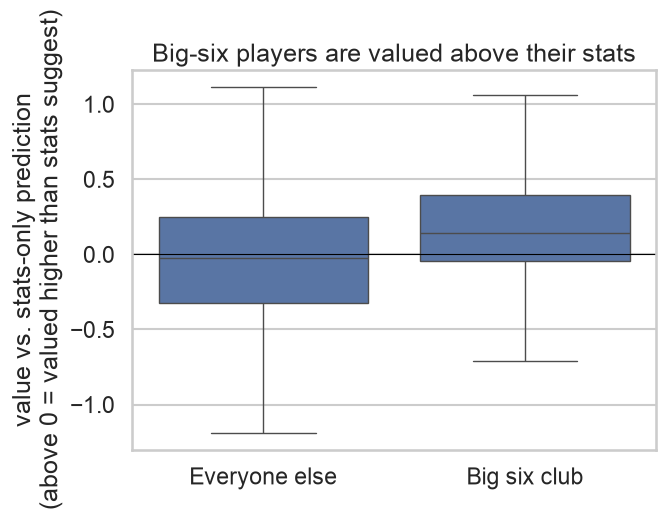

Big-six players are valued roughly 1.8x higher than their on-pitch stats alone would predict, compared to everyone else.


In [7]:
NUMERIC = ["age", "trailing_goals_per90", "trailing_assists_per90", "trailing_minutes", "trailing_appearances", "trailing_avg_club_position"]
CATEGORICAL = ["sub_position", "foot"]

model_df = panel.copy()
model_df["foot"] = model_df["foot"].fillna("unknown")
model_df["sub_position"] = model_df["sub_position"].fillna("unknown")
model_df["log_value"] = np.log10(model_df["current_value_eur"])
model_df = model_df.dropna(subset=NUMERIC + ["log_value"]).reset_index(drop=True)

preprocessor = ColumnTransformer([("num", StandardScaler(), NUMERIC), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])
stats_only_model = Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42))])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
predicted_log_value = cross_val_predict(stats_only_model, model_df[NUMERIC + CATEGORICAL], model_df["log_value"], cv=kfold)
model_df["value_gap"] = model_df["log_value"] - predicted_log_value

BIG_SIX = ["Arsenal", "Chelsea", "Liverpool", "Manchester City", "Manchester United", "Tottenham Hotspur"]
model_df["Big six?"] = np.where(model_df["current_club_name"].apply(lambda n: any(c in n for c in BIG_SIX)), "Big six club", "Everyone else")

gap_by_group = model_df.groupby("Big six?")["value_gap"].mean()
premium_multiplier = 10 ** (gap_by_group["Big six club"] - gap_by_group["Everyone else"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=model_df, x="Big six?", y="value_gap", ax=ax, showfliers=False)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("value vs. stats-only prediction\n(above 0 = valued higher than stats suggest)")
ax.set_xlabel(None)
ax.set_title("Big-six players are valued above their stats")
plt.tight_layout()
plt.show()

print(f"Big-six players are valued roughly {premium_multiplier:.1f}x higher than their on-pitch stats alone would predict, compared to everyone else.")

Interestingly, when we checked the same thing for a player's nationality (comparing players from football's biggest media markets — England, Brazil, France, Spain, Argentina, Germany — to everyone else), there was **no meaningful gap at all**. So the "reputation premium" here looks like a club-prestige story, not a where-are-you-from story.

## The bottom line

- Value peaks in the mid-20s, not at debut and not at 30+.
- Getting picked to play regularly matters as much as scoring goals.
- Attacking positions are paid a premium over defensive ones, even accounting for output.
- Big-six clubs come with a real value bump beyond what a player's stats justify — nationality doesn't.
- Every prediction here is pattern-matching on age, stats, and history. None of it knows about injuries, dressing-room politics, or a director of football's gut feeling — treat it as a starting point for an argument, not the final word.